<a href="https://colab.research.google.com/github/Yasir-Aladwani/clustering-mini-project/blob/main/clustering_mini_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##<font color='87BAC3'>**Clustering Mini Project: Apply & Compare Algorithms.**</font>

## <font color='lightgreen'>**Introduction**</font>

**Clustering is an unsupervised machine learning technique used to group similar data points based on their patterns and characteristics without using labeled outputs. It helps reveal hidden structures in data and is widely used in real-world applications such as customer segmentation, health analysis, market research, and anomaly detection.**

**In this project, we apply and compare three clustering algorithms: K-Means, DBSCAN, and Hierarchical Clustering. The goal is to understand how each algorithm behaves on the selected dataset, how the clustering results differ, and which algorithm is the most suitable based on data distribution, cluster shape, noise sensitivity, and evaluation metrics.**

**The project includes data preprocessing, feature scaling, clustering implementation, visualization of results, and a final comparison.**

## Libraries

In [2]:
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.cluster import AgglomerativeClustering

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

## Data Loading & Exploration

In [3]:
df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [5]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


## Feature Selection and Feature Scaling

In [6]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]
X_scaled = StandardScaler().fit_transform(X)

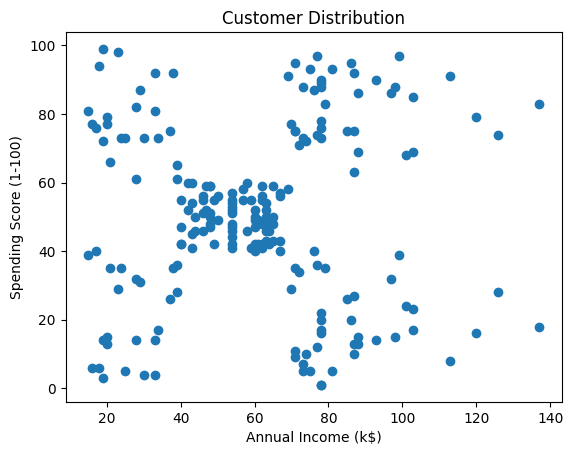

In [7]:
plt.scatter(X.iloc[:,0], X.iloc[:,1])
plt.title("Customer Distribution")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.show()

## Finding Optimal Clusters (Elbow Method)

In [8]:
inertia = []
for k in range(1,10):
  model = KMeans(n_clusters = k)
  model.fit(X_scaled)
  inertia.append(model.inertia_)

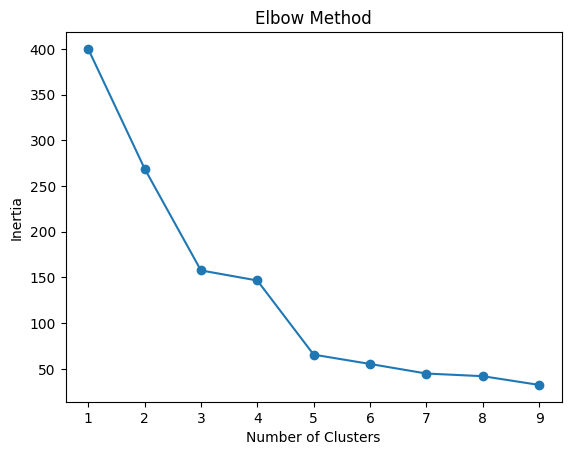

In [9]:
plt.plot(range(1,10), inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

## <font color='lightgreen'>**k means algorithm**</font>

In [10]:
kmeans = KMeans(n_clusters = 5, random_state=42)

clusters = kmeans.fit_predict(X_scaled)

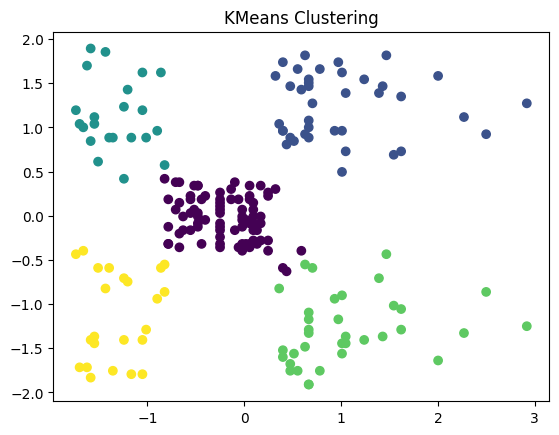

In [11]:
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=clusters, cmap="viridis")
plt.title("KMeans Clustering")
plt.show()

## Model Evaluation

In [12]:
score = silhouette_score(X_scaled, clusters)
print(f"Silhouette Score: {score:.4f}")

Silhouette Score: 0.5547


In [13]:
for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"K = {k}, Silhouette = {score:.4f}")

K = 2, Silhouette = 0.3973
K = 3, Silhouette = 0.4666
K = 4, Silhouette = 0.4943
K = 5, Silhouette = 0.5547
K = 6, Silhouette = 0.5138
K = 7, Silhouette = 0.5020
K = 8, Silhouette = 0.4550
K = 9, Silhouette = 0.4567


## <font color='lightgreen'>**DBSCAN algorithm**</font>

In [14]:
db = DBSCAN(eps=0.3, min_samples=3)
clusters_db = db.fit_predict(X_scaled)

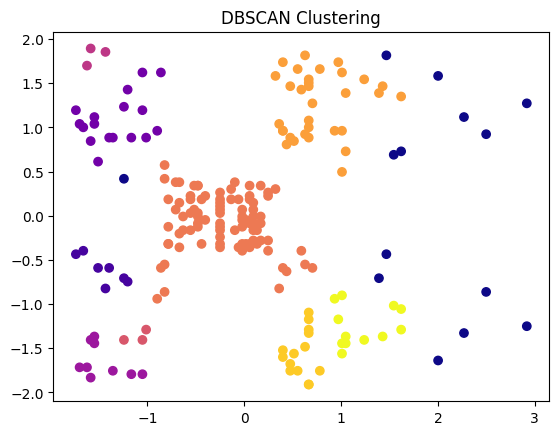

Silhouette Score: 0.4136


In [15]:
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=clusters_db, cmap="plasma")
plt.title("DBSCAN Clustering")
plt.show()
score = silhouette_score(X_scaled, clusters_db)
print(f"Silhouette Score: {score:.4f}")

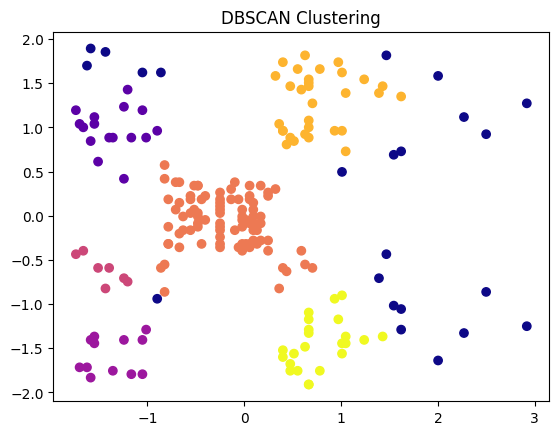

Silhouette Score: 0.4368


In [16]:
db = DBSCAN(eps=0.35, min_samples=5)
clusters_db = db.fit_predict(X_scaled)
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=clusters_db, cmap="plasma")
plt.title("DBSCAN Clustering")
plt.show()
score = silhouette_score(X_scaled, clusters_db)
print(f"Silhouette Score: {score:.4f}")

## <font color='lightgreen'>**Hierarchical Clustering**</font>

<h3> With 5 cluster and 2 feature

In [17]:
score_dict = {}

In [18]:
scaler = StandardScaler()
df_stand = scaler.fit_transform(df[["Annual Income (k$)","Spending Score (1-100)"]])

In [19]:
hc = AgglomerativeClustering(n_clusters=3)

clusters_hc = hc.fit_predict(df_stand)

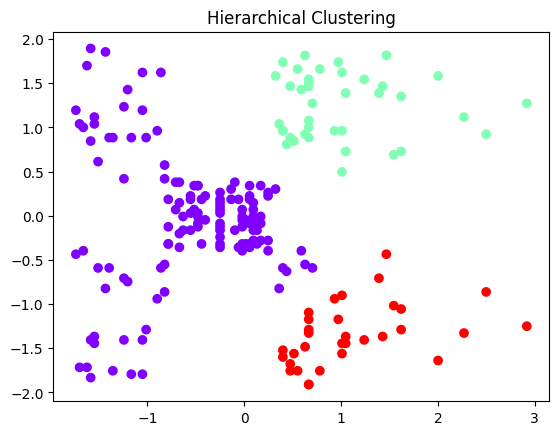

In [20]:
plt.scatter(df_stand[:,0], df_stand[:,1], c=clusters_hc, cmap="rainbow")
plt.title("Hierarchical Clustering")
plt.show()

In [21]:
score_dict["HC with 3 cluster and 2 feature"]=silhouette_score(df_stand, clusters_hc)

In [22]:
df_stand = scaler.fit_transform(df[["Age","Annual Income (k$)","Spending Score (1-100)"]])

In [23]:
pca = PCA(n_components=2)

df_pca = pca.fit_transform(df_stand)

<h2> 3 feature and PCA

## <font color='lightgreen'>**number of clusters 3**</font>

In [24]:
hc = AgglomerativeClustering(n_clusters=3)

clusters_hc = hc.fit_predict(df_pca)

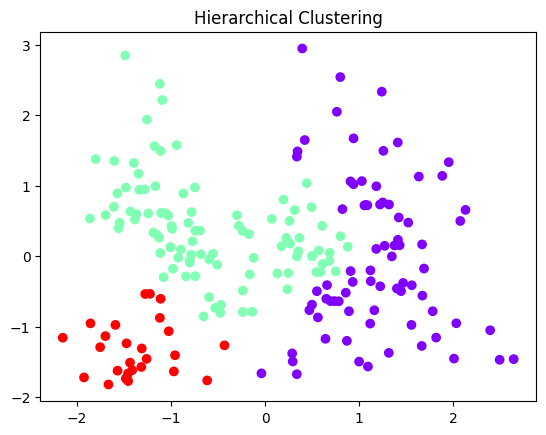

In [25]:
plt.scatter(df_pca[:,0], df_pca[:,1], c=clusters_hc, cmap="rainbow")
plt.title("Hierarchical Clustering")
plt.show()

In [26]:
score_dict["HC with 3 cluster"]=silhouette_score(df_pca, clusters_hc)

## <font color='lightgreen'>**number of clusters 5**</font>

In [27]:
hc = AgglomerativeClustering(n_clusters=5)

clusters_hc = hc.fit_predict(df_pca)

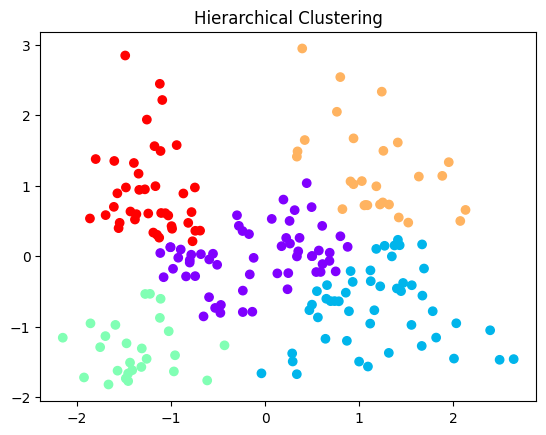

In [28]:
plt.scatter(df_pca[:,0], df_pca[:,1], c=clusters_hc, cmap="rainbow")
plt.title("Hierarchical Clustering")
plt.show()

In [29]:
score_dict["HC with 5 cluster"]=silhouette_score(df_pca, clusters_hc)

<h2> Diffrenet linking method

<h3> ward

In [30]:
hc = AgglomerativeClustering(n_clusters=5,linkage="ward")

clusters_hc = hc.fit_predict(df_pca)

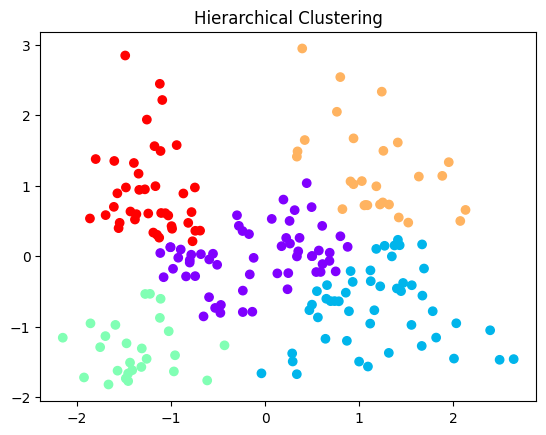

In [31]:
plt.scatter(df_pca[:,0], df_pca[:,1], c=clusters_hc, cmap="rainbow")
plt.title("Hierarchical Clustering")
plt.show()

In [32]:
score_dict["HC with 5 cluster and ward linkage"]=silhouette_score(df_pca, clusters_hc)

<h3> average

In [33]:
hc = AgglomerativeClustering(n_clusters=5,linkage="average")

clusters_hc = hc.fit_predict(df_pca)

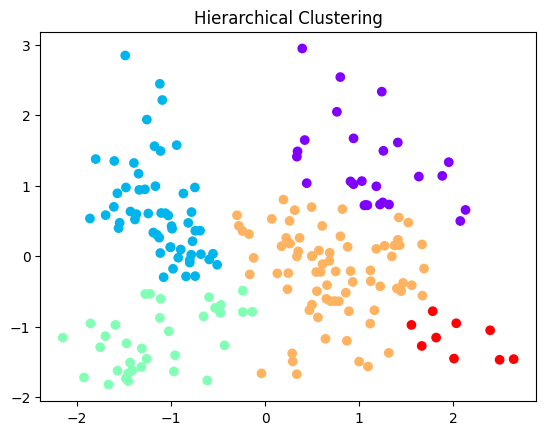

In [34]:
plt.scatter(df_pca[:,0], df_pca[:,1], c=clusters_hc, cmap="rainbow")
plt.title("Hierarchical Clustering")
plt.show()

In [35]:
score_dict["HC with 5 cluster and average linkage"]=silhouette_score(df_pca, clusters_hc)

<h3>complete

In [36]:
hc = AgglomerativeClustering(n_clusters=5,linkage="complete")

clusters_hc = hc.fit_predict(df_pca)

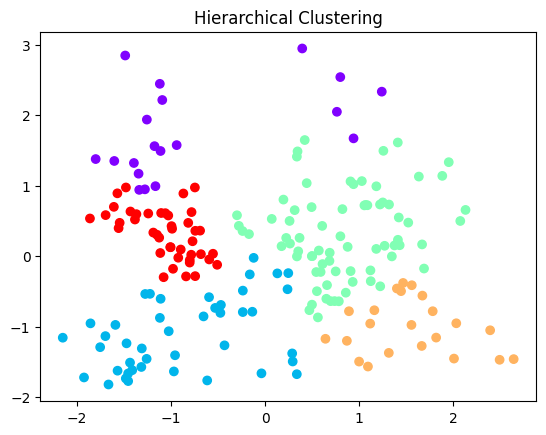

In [37]:
plt.scatter(df_pca[:,0], df_pca[:,1], c=clusters_hc, cmap="rainbow")
plt.title("Hierarchical Clustering")
plt.show()

In [38]:
score_dict["HC with 5 cluster and complete linkage"]=silhouette_score(df_pca, clusters_hc)

<h3>single

In [39]:
hc = AgglomerativeClustering(n_clusters=5,linkage="single")

clusters_hc = hc.fit_predict(df_pca)

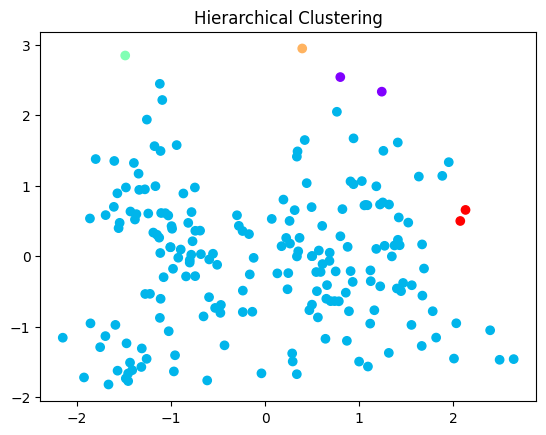

In [40]:
plt.scatter(df_pca[:,0], df_pca[:,1], c=clusters_hc, cmap="rainbow")
plt.title("Hierarchical Clustering")
plt.show()

In [41]:
score_dict["HC with 5 cluster and single linkage"]=silhouette_score(df_pca, clusters_hc)

In [42]:
for method, score in score_dict.items():
    print(f"The {method} has score of {int(score*100)}%")

The HC with 3 cluster and 2 feature has score of 46%
The HC with 3 cluster has score of 32%
The HC with 5 cluster has score of 38%
The HC with 5 cluster and ward linkage has score of 38%
The HC with 5 cluster and average linkage has score of 38%
The HC with 5 cluster and complete linkage has score of 31%
The HC with 5 cluster and single linkage has score of 7%


##Comparing K-Means, DBSCAN, and Hierarchical Clustering

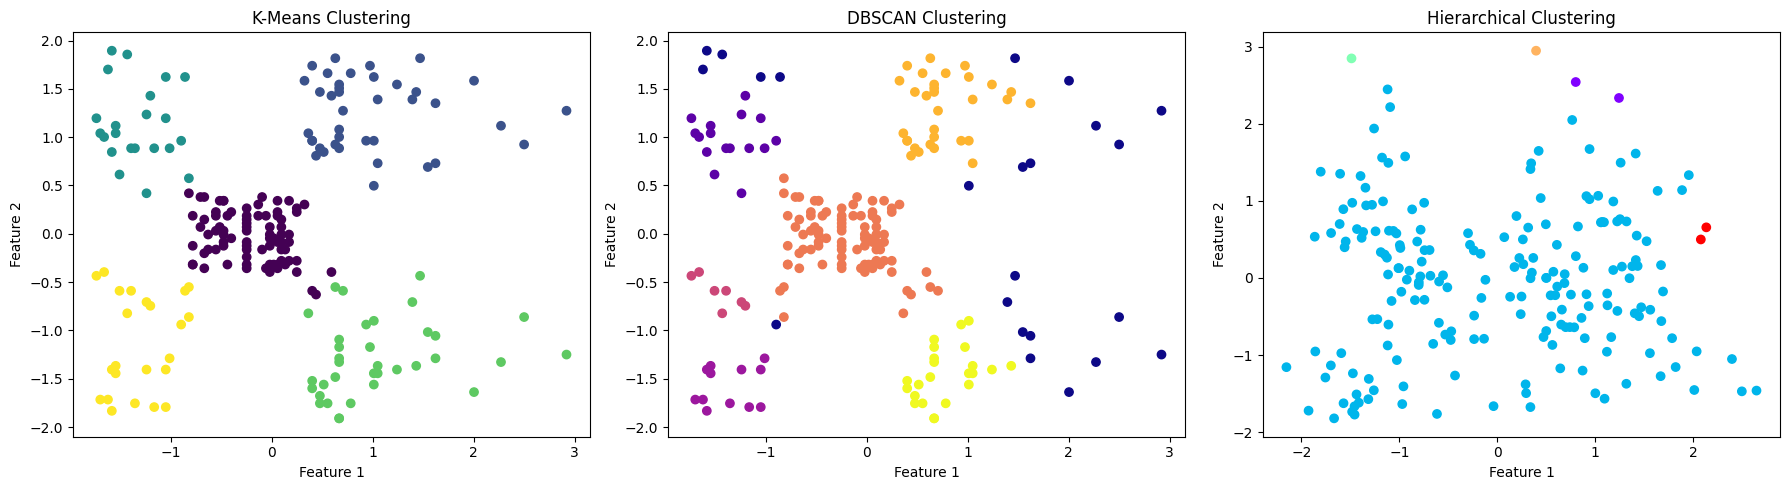

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# K-Means
axes[0].scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters, cmap="viridis")
axes[0].set_title("K-Means Clustering")
axes[0].set_xlabel("Feature 1")
axes[0].set_ylabel("Feature 2")

# DBSCAN
axes[1].scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters_db, cmap="plasma")
axes[1].set_title("DBSCAN Clustering")
axes[1].set_xlabel("Feature 1")
axes[1].set_ylabel("Feature 2")

# Hierarchical Clustering
plt.scatter(df_pca[:,0], df_pca[:,1], c=clusters_hc, cmap="rainbow")
plt.title("Hierarchical Clustering")
axes[2].set_xlabel("Feature 1")
axes[2].set_ylabel("Feature 2")

plt.tight_layout()
plt.show()

- Best visual separation: K-Means
- Best for noise and outliers: DBSCAN
- Weakest result in this plot: Hierarchical Clustering

## What is Clustering?

Clustering is an **unsupervised learning** technique used to group similar data points together.  
The goal is to place data points with similar characteristics in the same cluster, while separating points that are different into other clusters.

In simple words, clustering helps us **discover hidden patterns or natural groups in the data** without having predefined labels.

---

## K-Means Clustering

**K-Means** is a clustering algorithm that divides data into a fixed number of groups chosen in advance.  
It works by assigning each data point to the nearest cluster center, then updating the centers until the clusters become stable.

### When to Use It
- When the number of clusters is already known
- When you want a simple and fast clustering method
- When the data is relatively clean
- When clusters are compact and well separated

### Important Parameter
- **n_clusters**: The number of clusters to create


### Key Idea
K-Means focuses on finding the **center (centroid)** of each cluster.

---

## DBSCAN Clustering

**DBSCAN** is a density-based clustering algorithm.  
It groups together points that are closely packed and labels points in low-density regions as **noise** or **outliers**.

### When to Use It
- When the number of clusters is unknown
- When the data contains outliers
- When clusters may have irregular shapes
- When you want to discover natural groupings in the data

### Important Parameters
- **eps**: The maximum distance between two points to be considered neighbors
- **min_samples**: Minimum number of points required to form a dense region

### Key Idea
DBSCAN focuses on **density**, not on predefined centers.

---

## Hierarchical Clustering

**Hierarchical Clustering** builds clusters step by step by merging the closest points or groups.  
The result can be visualized using a **dendrogram**, which shows how clusters are formed gradually.

### When to Use It
- When you want to understand how clusters are related
- When you want a hierarchy of clusters
- When visualization is important
- When you want to explore clustering at multiple levels

### Important Parameters
- **n_clusters**: The number of clusters to form
- **linkage**: The method used to measure the distance between clusters

### Key Idea
Hierarchical Clustering focuses on the **relationship between points and groups at different levels**.

---

## Key Questions to Solve the Scenarios

Before choosing the algorithm, think about these questions:

1. **Is the number of clusters known in advance?**
2. **Does the data contain outliers or noise?**
3. **Do we want to see how groups are related step by step?**

## Clustering in Real-World Scenarios

### Scenario 1
A restaurant company wants to divide its branches into **3 clear groups** based on the **number of orders** and **average sales**.  
**Which clustering algorithm would be the most suitable?**

---

### Scenario 2
A transportation company wants to identify the **actual gathering points of buses** in the city, with some buses located **far away from the main groups**.  
**Which clustering algorithm would be the most suitable?**

---

### Scenario 3
A training company wants to create a **visual structure** showing how courses are related, starting from **small topics** and building up into **larger learning paths**.  
**Which clustering algorithm would be the most suitable?**

---

### Scenario 4
A telecom company already knows that it wants to divide its customers into **4 groups** based on **data usage** and **number of calls**.  
**Which clustering algorithm would be the most suitable?**

---

### Scenario 5
An electronics company wants to understand how its products are grouped, starting from **similar devices** and moving into **larger categories** such as phones, computers, and home appliances.  
**Which clustering algorithm would be the most suitable?**

---

### Scenario 6
A delivery company wants to discover areas where orders **naturally cluster** in the city, with a few **isolated orders** far from the others.  
**Which clustering algorithm would be the most suitable?**